# Loss Landscape & Gradient Analysis — Differentiable Karplus-Strong

For each synthesis parameter, freeze all others at ground truth and sweep the
target parameter across its valid range. Compute the **loss** and **analytic gradient**
under both Time-Domain and Frequency-Sampling implementations.

Inspired by Figure 5 of Masuda & Saito (2023).

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from tqdm.auto import tqdm

from src.synths.synth import Synth, SynthConfig
from src.synths.ddsp import Implementation
from src.losses import MultiScaleSpectralLoss, SOT2048Loss
from src.synths.param_registry import (
    PLUCK_POSITION_MIN, PLUCK_POSITION_MAX,
    DAMPING_MIN, DAMPING_MAX,
    DECAY_MIN, DECAY_MAX,
    DYNAMIC_LEVEL_MIN, DYNAMIC_LEVEL_MAX,
    F0_MIN_HZ, F0_MAX_HZ,
    BURST_GAIN_MAX,
)

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

## Configuration

In [23]:
FS = 16000
NUM_SAMPLES = 64000          # 4 s
N_SWEEP = 200                # points per parameter
TRIM_PCT = 0.02              # trim 2% from each edge
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Ground-truth event — single pluck at t = 0.30
# 0.30 * 64000 = 19200 → exact sample boundary
GT_ONSET = 0.30

GT_PARAMS = {
    "exists":         torch.ones(1, 1),
    "time":           torch.tensor([[GT_ONSET]]),
    "f0":             torch.tensor([[220.0]]),
    "burst_gain":     torch.tensor([[0.9]]),
    "pluck_position": torch.tensor([[0.25]]),
    "dynamic_level":  torch.tensor([[0.5]]),
    "a1":             torch.tensor([[0.3]]),
    "decay":          torch.tensor([[0.995]]),
}

# Sweep ranges — 2% trimmed from edges to avoid boundary spikes
def _trimmed_range(lo, hi):
    margin = (hi - lo) * TRIM_PCT
    return lo + margin, hi - margin

SWEEP_CFG = {
    "f0":             {"lo": F0_MIN_HZ,                "hi": F0_MAX_HZ,           "label": r"$f_0$ (Hz)"},
    "decay":          {"lo": DECAY_MIN,                "hi": DECAY_MAX,           "label": r"Decay $g$"},
    "a1":             {"lo": DAMPING_MIN,              "hi": DAMPING_MAX,         "label": r"Damping $a_1$"},
    "pluck_position": {"lo": PLUCK_POSITION_MIN,       "hi": PLUCK_POSITION_MAX,  "label": r"Pluck position"},
    "dynamic_level":  {"lo": DYNAMIC_LEVEL_MIN,        "hi": DYNAMIC_LEVEL_MAX,   "label": r"Dynamic level"},
    "burst_gain":     {"lo": 0.0,                      "hi": BURST_GAIN_MAX,      "label": r"Burst gain"},
    "time":           {"lo": 0.0,                      "hi": 0.75,                "label": r"Onset time $t$"},
}

# Apply trim
for k in SWEEP_CFG:
    lo, hi = _trimmed_range(SWEEP_CFG[k]['lo'], SWEEP_CFG[k]['hi'])
    SWEEP_CFG[k]['lo'] = lo
    SWEEP_CFG[k]['hi'] = hi

PARAM_ORDER = ["f0", "decay", "a1", "pluck_position", "dynamic_level", "burst_gain", "time"]

Device: cpu


## Build synthesisers and loss functions

In [24]:
synth_oracle = Synth(SynthConfig(num_samples=NUM_SAMPLES, fs=FS))

synth_td = Synth(SynthConfig(
    num_samples=NUM_SAMPLES, fs=FS,
    implementation=Implementation.TIME_DOMAIN,
))

synth_fs = Synth(SynthConfig(
    num_samples=NUM_SAMPLES, fs=FS,
    implementation=Implementation.FREQUENCY_SAMPLING,
    n_fft=NUM_SAMPLES,
    use_lti=True,
))

for s in (synth_oracle, synth_td, synth_fs):
    s.to(DEVICE)

mss_fn = MultiScaleSpectralLoss().to(DEVICE)
sot_fn = SOT2048Loss(sample_rate=FS)

## Render oracle target

In [25]:
def _to_device(params: dict) -> dict:
    return {k: v.to(DEVICE) for k, v in params.items()}


with torch.no_grad():
    target_audio, _ = synth_oracle.oracle_synth(_to_device(GT_PARAMS))

print(f"Target audio — shape: {target_audio.shape}, peak: {target_audio.abs().max():.4f}")

# Stash numpy for plots
target_np = target_audio[0].cpu().numpy()

Target audio — shape: torch.Size([1, 64000]), peak: 0.1420


## Target — Waveform & Spectrogram

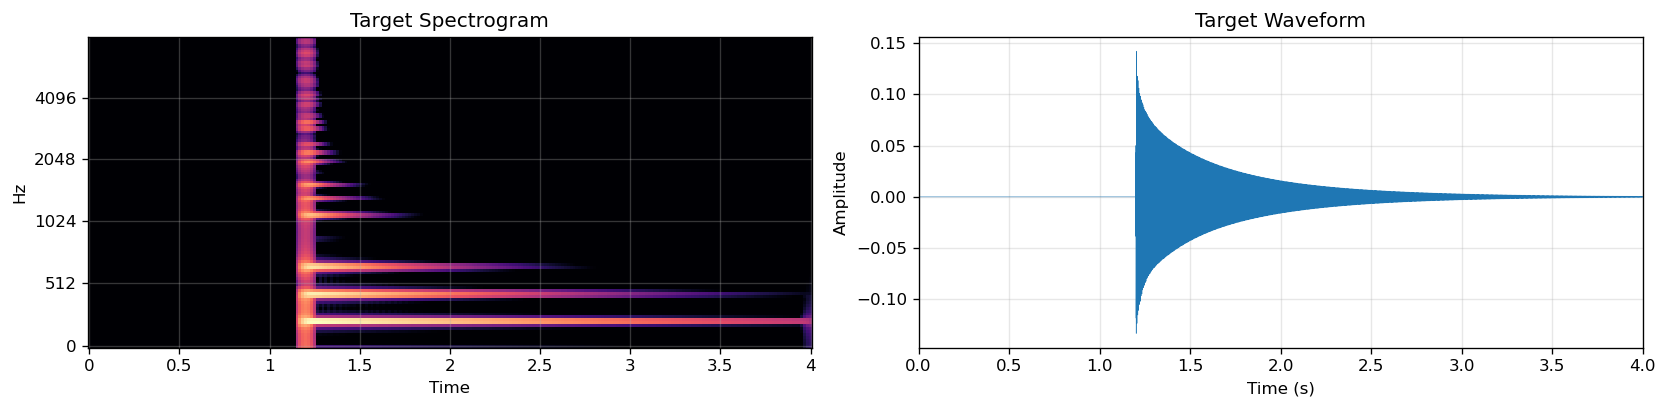

In [26]:
fig, (ax_spec, ax_wav) = plt.subplots(1, 2, figsize=(14, 3.5))

S = librosa.feature.melspectrogram(y=target_np, sr=FS, n_fft=2048, hop_length=256, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_db, sr=FS, hop_length=256, x_axis='time', y_axis='mel', ax=ax_spec)
ax_spec.set_title("Target Spectrogram")

t_axis = np.arange(NUM_SAMPLES) / FS
ax_wav.plot(t_axis, target_np, linewidth=0.3, color='tab:blue')
ax_wav.set_xlabel("Time (s)")
ax_wav.set_ylabel("Amplitude")
ax_wav.set_title("Target Waveform")
ax_wav.set_xlim(0, NUM_SAMPLES / FS)

fig.tight_layout()
plt.show()

## Sweep & gradient computation helpers

In [54]:
def compute_landscape_with_grad(
    synth: Synth,
    loss_fn,
    sweep_key: str,
    sweep_values: np.ndarray,
    gt_params: dict[str, torch.Tensor],
    target_audio: torch.Tensor,
    desc: str = "",
) -> tuple[np.ndarray, np.ndarray]:
    """Sweep *sweep_key*, return (loss_vals, grad_vals)."""
    N = len(sweep_values)
    losses = np.empty(N)
    grads = np.empty(N)

    for i in tqdm(range(N), desc=desc, leave=False):
        val = sweep_values[i]
        params = {k: v.clone().detach() for k, v in gt_params.items()}
        p = torch.tensor(
            [[float(val)]], dtype=torch.float32, device=DEVICE, requires_grad=True
        )
        params[sweep_key] = p

        audio, _ = synth(params)
        loss = loss_fn(audio, target_audio)
        loss.backward()

        losses[i] = loss.item()
        grads[i] = p.grad.item() if p.grad is not None else 0.0

    return losses, grads


SHADE_ALPHA = 0.25
SHADE_COLOR = 'tab:red'


def _shade_correct_gradient_regions(ax, sweep, gt_val):
    """Shade rectangular regions where gradient SHOULD be correct:
    - Left of GT & below y=0  (gradient should be negative)
    - Right of GT & above y=0 (gradient should be positive)"""
    ylim = ax.get_ylim()

    # Left of GT, below zero
    ax.fill_between(
        [sweep[0], gt_val], ylim[0], 0,
        alpha=SHADE_ALPHA, color=SHADE_COLOR, zorder=0, linewidth=0,
    )
    # Right of GT, above zero
    ax.fill_between(
        [gt_val, sweep[-1]], 0, ylim[1],
        alpha=SHADE_ALPHA, color=SHADE_COLOR, zorder=0, linewidth=0,
    )

    # Restore ylim (fill_between can nudge it)
    ax.set_ylim(ylim)


def plot_loss_and_grad(
    sweep, gt_val, label,
    td_loss, td_grad, fs_loss, fs_grad,
    loss_name: str,
):
    """Plot loss + gradient side by side."""
    fig, (ax_loss, ax_grad) = plt.subplots(1, 2, figsize=(14, 4))

    # ── Loss panel ──
    ax_loss.plot(sweep, td_loss, label="Time-domain",   color="tab:blue",   linewidth=1.5)
    ax_loss.plot(sweep, fs_loss, label="Freq-sampling", color="tab:orange", linewidth=1.5, linestyle="--")
    ax_loss.axvline(gt_val, color="tab:green", linestyle=":", linewidth=1.5, alpha=0.8, label="Target")
    ax_loss.set_xlabel(label)
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"Loss: {loss_name} — {label}")
    ax_loss.legend(fontsize=8)

    # ── Gradient panel ──
    ax_grad.plot(sweep, td_grad, label="Time-domain",   color="tab:blue",   linewidth=1.5)
    ax_grad.plot(sweep, fs_grad, label="Freq-sampling", color="tab:orange", linewidth=1.5, linestyle="--")
    ax_grad.axvline(gt_val, color="tab:green", linestyle=":", linewidth=1.5, alpha=0.8, label="GT")
    ax_grad.axhline(0, color="black", linewidth=0.5, alpha=0.5)
    ax_grad.set_xlabel(label)
    ax_grad.set_ylabel(r"$\frac{\partial \mathcal{L}}{\partial \theta}$")
    ax_grad.set_title(f"Grad: {loss_name} — {label}")
    ax_grad.legend(fontsize=8)

    # Shading AFTER plotting so ylim is set by data
    _shade_correct_gradient_regions(ax_grad, sweep, gt_val)

    for ax in (ax_loss, ax_grad):
        ax.set_xlim(sweep[0], sweep[-1])

    fig.tight_layout()
    plt.show()

---
## `f0`

Sweeping f0 — GT = 220.0000, range = [59.4690, 1151.9010]


f0 MSS TD:   0%|          | 0/200 [00:00<?, ?it/s]

f0 MSS FS:   0%|          | 0/200 [00:00<?, ?it/s]

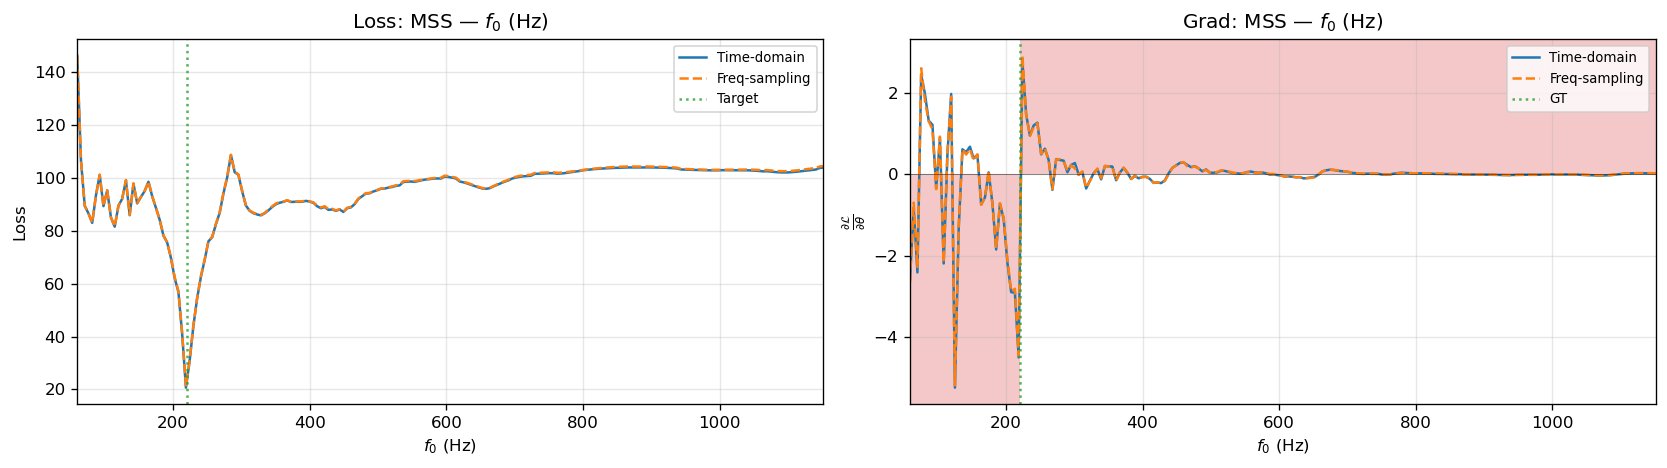

f0 SOT TD:   0%|          | 0/200 [00:00<?, ?it/s]

f0 SOT FS:   0%|          | 0/200 [00:00<?, ?it/s]

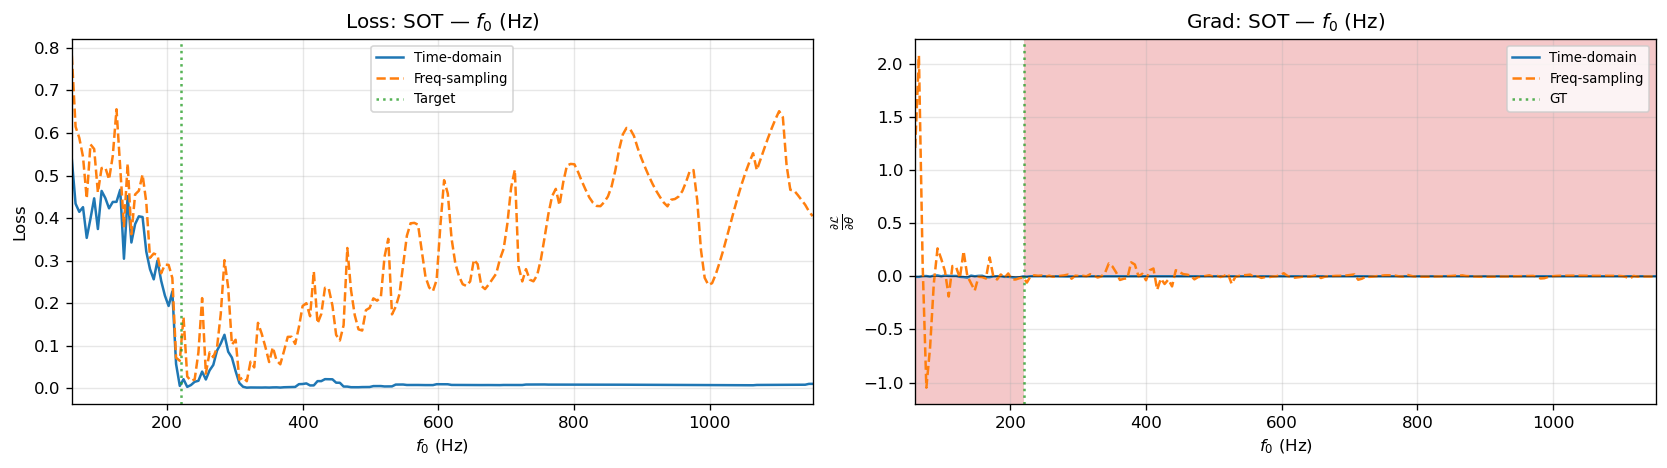

In [36]:
key = "f0"
cfg = SWEEP_CFG[key]
sweep = np.linspace(cfg["lo"], cfg["hi"], N_SWEEP)
gt = _to_device(GT_PARAMS)
gt_val = GT_PARAMS[key].item()

print(f"Sweeping {key} — GT = {gt_val:.4f}, range = [{cfg['lo']:.4f}, {cfg['hi']:.4f}]")

# ── MSS ──
mss_td_loss, mss_td_grad = compute_landscape_with_grad(
    synth_td, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS TD")
mss_fs_loss, mss_fs_grad = compute_landscape_with_grad(
    synth_fs, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   mss_td_loss, mss_td_grad, mss_fs_loss, mss_fs_grad, "MSS")

# ── SOT ──
sot_td_loss, sot_td_grad = compute_landscape_with_grad(
    synth_td, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT TD")
sot_fs_loss, sot_fs_grad = compute_landscape_with_grad(
    synth_fs, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   sot_td_loss, sot_td_grad, sot_fs_loss, sot_fs_grad, "SOT")

# ── Stash for summary ──
if "results" not in dir(): results = {}
results[key] = {
    "sweep": sweep, "gt": gt_val, "label": cfg["label"],
    "mss_td": (mss_td_loss, mss_td_grad),
    "mss_fs": (mss_fs_loss, mss_fs_grad),
    "sot_td": (sot_td_loss, sot_td_grad),
    "sot_fs": (sot_fs_loss, sot_fs_grad),
}

---
## `decay`

Sweeping decay — GT = 0.9950, range = [0.9020, 0.9980]


decay MSS TD:   0%|          | 0/200 [00:00<?, ?it/s]

decay MSS FS:   0%|          | 0/200 [00:00<?, ?it/s]

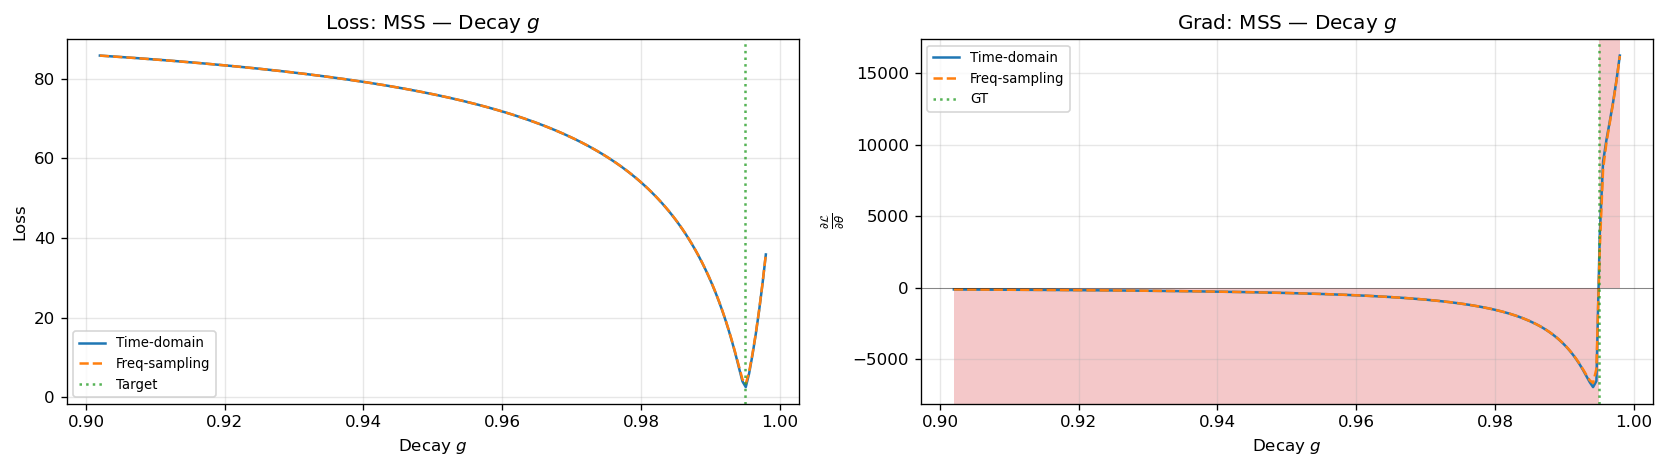

decay SOT TD:   0%|          | 0/200 [00:00<?, ?it/s]

decay SOT FS:   0%|          | 0/200 [00:00<?, ?it/s]

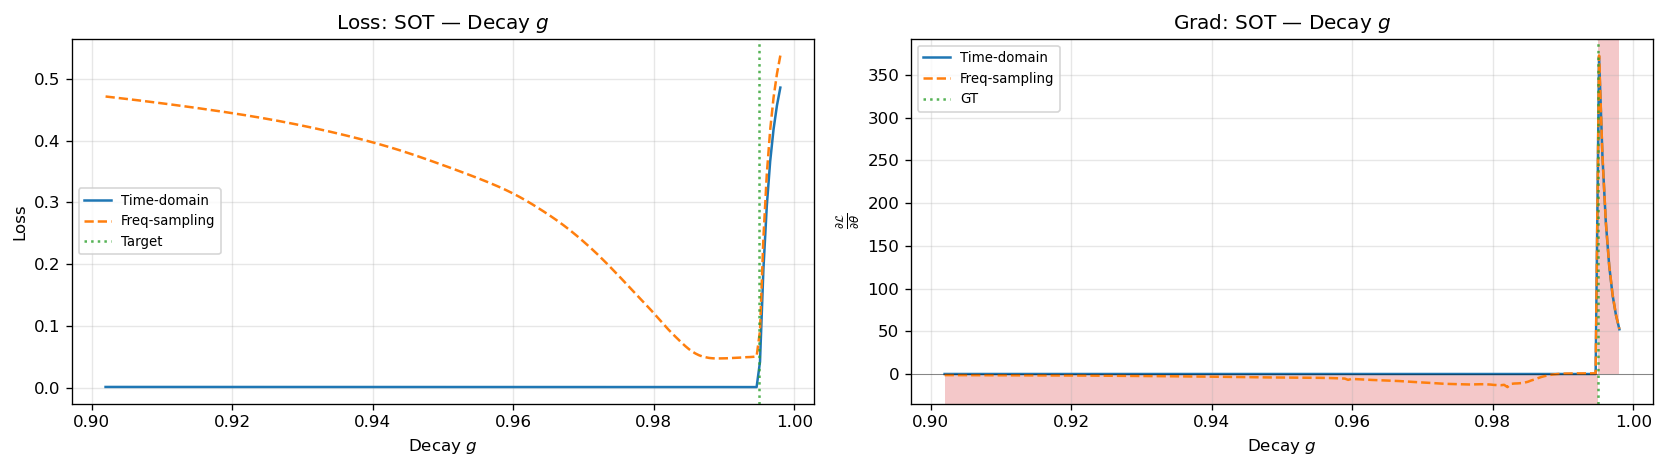

In [19]:
key = "decay"
cfg = SWEEP_CFG[key]
sweep = np.linspace(cfg["lo"], cfg["hi"], N_SWEEP)
gt = _to_device(GT_PARAMS)
gt_val = GT_PARAMS[key].item()

print(f"Sweeping {key} — GT = {gt_val:.4f}, range = [{cfg['lo']:.4f}, {cfg['hi']:.4f}]")

# ── MSS ──
mss_td_loss, mss_td_grad = compute_landscape_with_grad(
    synth_td, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS TD")
mss_fs_loss, mss_fs_grad = compute_landscape_with_grad(
    synth_fs, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   mss_td_loss, mss_td_grad, mss_fs_loss, mss_fs_grad, "MSS")

# ── SOT ──
sot_td_loss, sot_td_grad = compute_landscape_with_grad(
    synth_td, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT TD")
sot_fs_loss, sot_fs_grad = compute_landscape_with_grad(
    synth_fs, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   sot_td_loss, sot_td_grad, sot_fs_loss, sot_fs_grad, "SOT")

# ── Stash for summary ──
if "results" not in dir(): results = {}
results[key] = {
    "sweep": sweep, "gt": gt_val, "label": cfg["label"],
    "mss_td": (mss_td_loss, mss_td_grad),
    "mss_fs": (mss_fs_loss, mss_fs_grad),
    "sot_td": (sot_td_loss, sot_td_grad),
    "sot_fs": (sot_fs_loss, sot_fs_grad),
}

---
## `a1`

Sweeping a1 — GT = 0.3000, range = [0.0150, 0.7350]


a1 MSS TD:   0%|          | 0/200 [00:00<?, ?it/s]

a1 MSS FS:   0%|          | 0/200 [00:00<?, ?it/s]

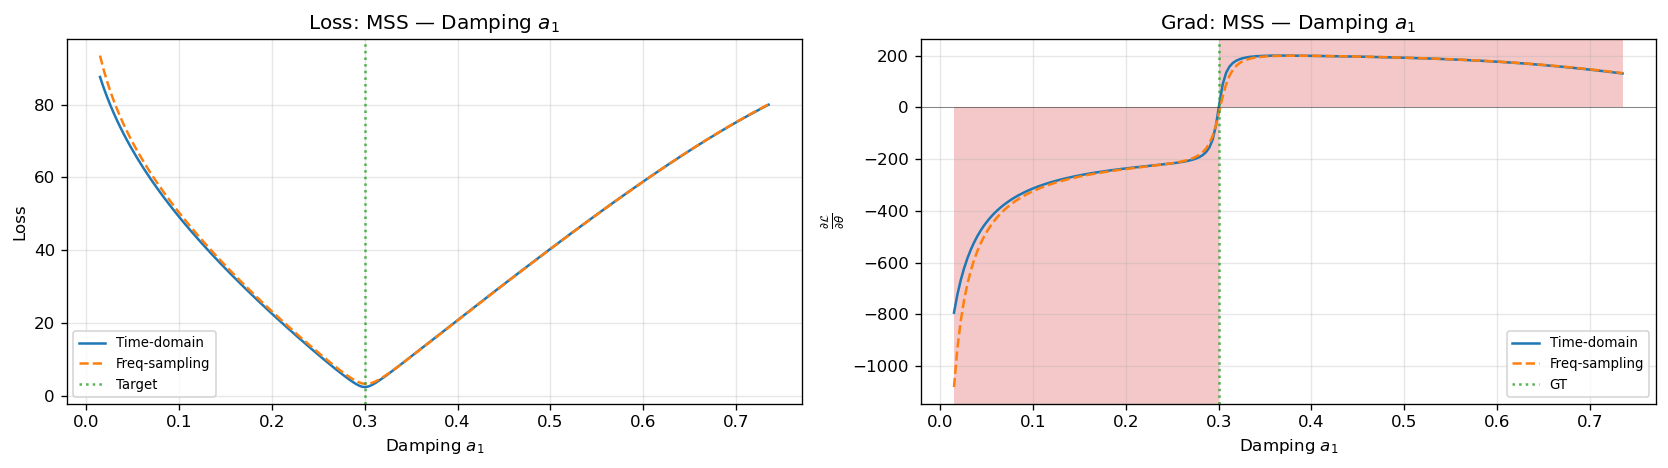

a1 SOT TD:   0%|          | 0/200 [00:00<?, ?it/s]

a1 SOT FS:   0%|          | 0/200 [00:00<?, ?it/s]

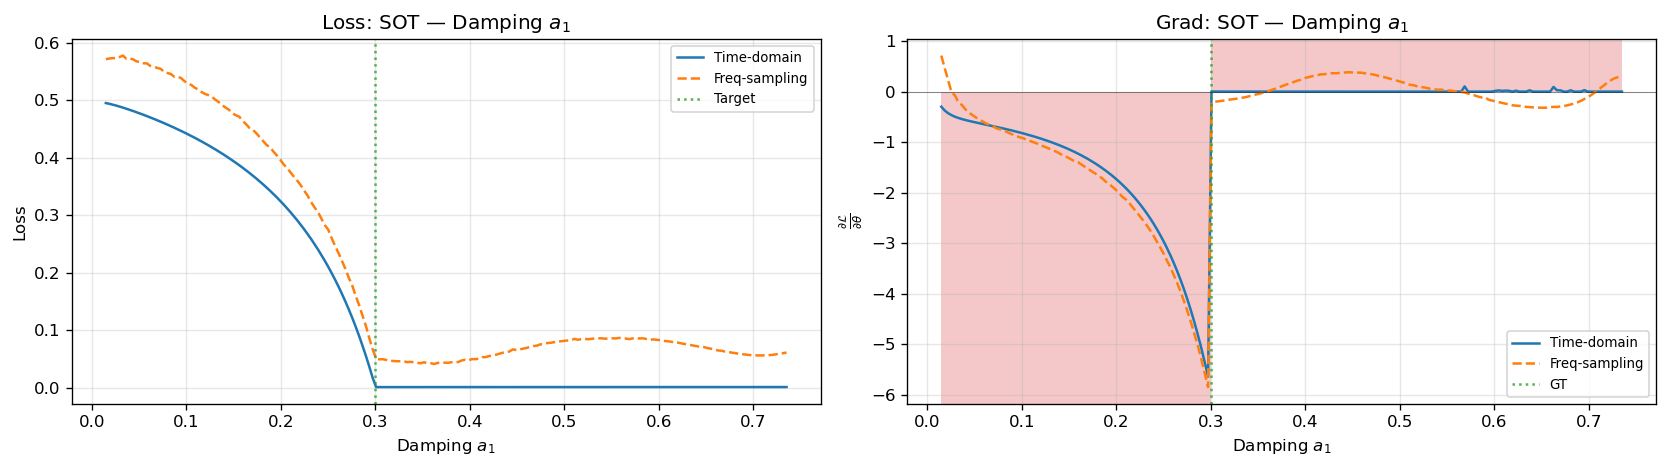

In [20]:
key = "a1"
cfg = SWEEP_CFG[key]
sweep = np.linspace(cfg["lo"], cfg["hi"], N_SWEEP)
gt = _to_device(GT_PARAMS)
gt_val = GT_PARAMS[key].item()

print(f"Sweeping {key} — GT = {gt_val:.4f}, range = [{cfg['lo']:.4f}, {cfg['hi']:.4f}]")

# ── MSS ──
mss_td_loss, mss_td_grad = compute_landscape_with_grad(
    synth_td, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS TD")
mss_fs_loss, mss_fs_grad = compute_landscape_with_grad(
    synth_fs, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   mss_td_loss, mss_td_grad, mss_fs_loss, mss_fs_grad, "MSS")

# ── SOT ──
sot_td_loss, sot_td_grad = compute_landscape_with_grad(
    synth_td, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT TD")
sot_fs_loss, sot_fs_grad = compute_landscape_with_grad(
    synth_fs, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   sot_td_loss, sot_td_grad, sot_fs_loss, sot_fs_grad, "SOT")

# ── Stash for summary ──
if "results" not in dir(): results = {}
results[key] = {
    "sweep": sweep, "gt": gt_val, "label": cfg["label"],
    "mss_td": (mss_td_loss, mss_td_grad),
    "mss_fs": (mss_fs_loss, mss_fs_grad),
    "sot_td": (sot_td_loss, sot_td_grad),
    "sot_fs": (sot_fs_loss, sot_fs_grad),
}

---
## `pluck_position`

Sweeping pluck_position — GT = 0.2500, range = [0.0198, 0.4902]


pluck_position MSS TD:   0%|          | 0/200 [00:00<?, ?it/s]

pluck_position MSS FS:   0%|          | 0/200 [00:00<?, ?it/s]

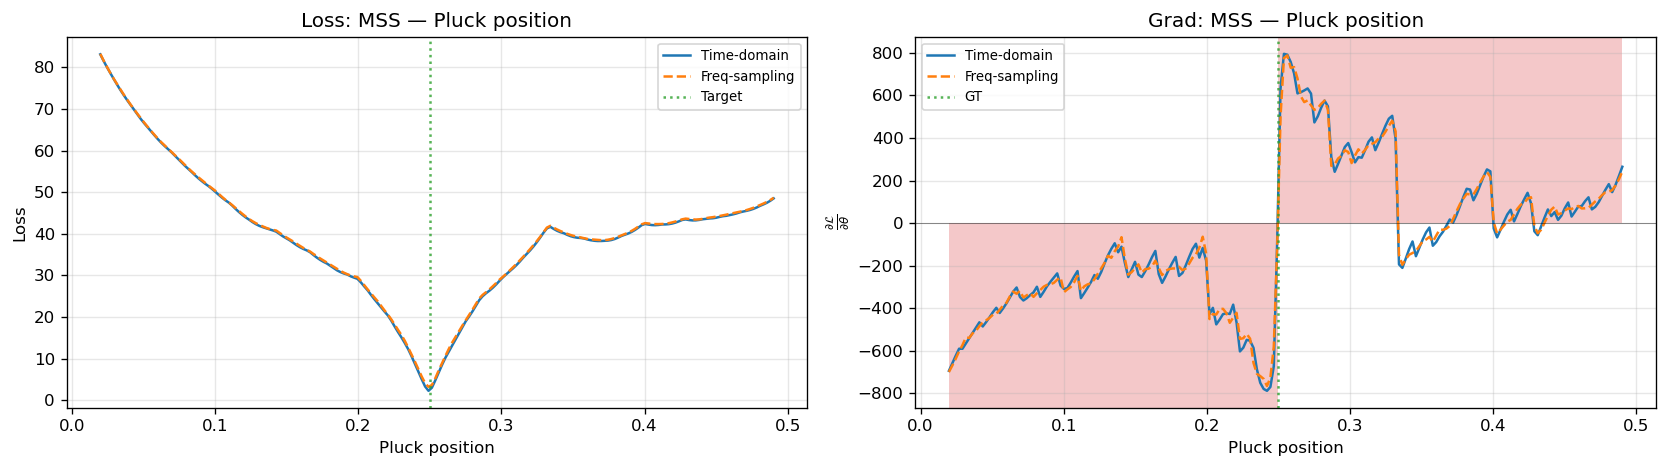

pluck_position SOT TD:   0%|          | 0/200 [00:00<?, ?it/s]

pluck_position SOT FS:   0%|          | 0/200 [00:00<?, ?it/s]

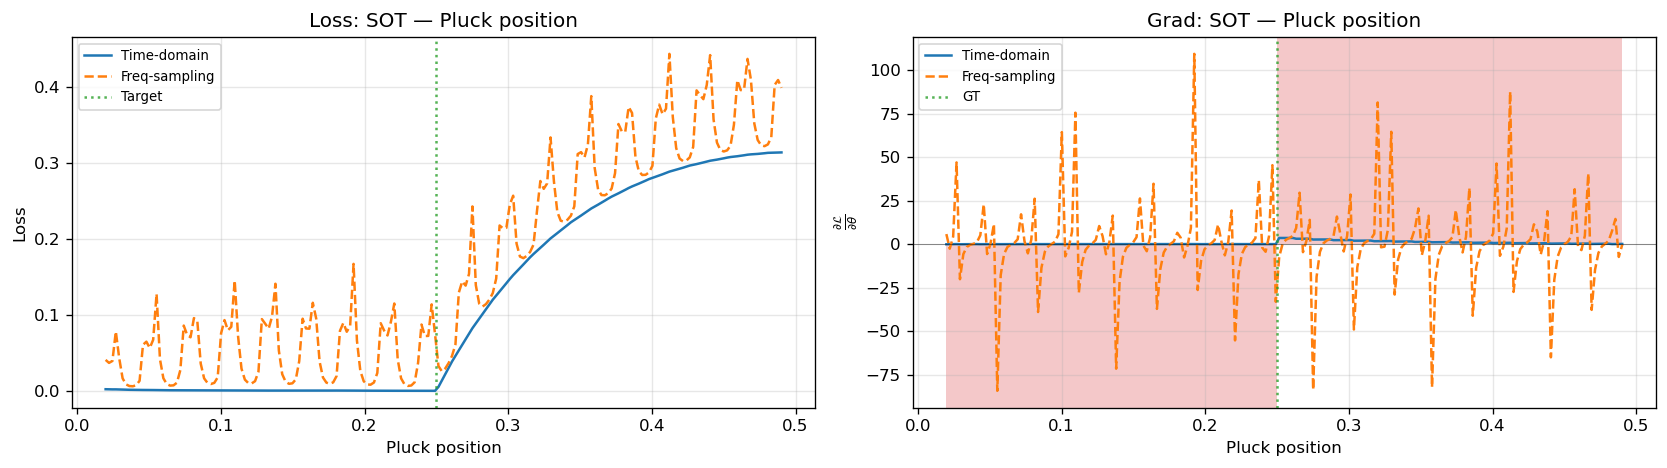

In [21]:
key = "pluck_position"
cfg = SWEEP_CFG[key]
sweep = np.linspace(cfg["lo"], cfg["hi"], N_SWEEP)
gt = _to_device(GT_PARAMS)
gt_val = GT_PARAMS[key].item()

print(f"Sweeping {key} — GT = {gt_val:.4f}, range = [{cfg['lo']:.4f}, {cfg['hi']:.4f}]")

# ── MSS ──
mss_td_loss, mss_td_grad = compute_landscape_with_grad(
    synth_td, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS TD")
mss_fs_loss, mss_fs_grad = compute_landscape_with_grad(
    synth_fs, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   mss_td_loss, mss_td_grad, mss_fs_loss, mss_fs_grad, "MSS")

# ── SOT ──
sot_td_loss, sot_td_grad = compute_landscape_with_grad(
    synth_td, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT TD")
sot_fs_loss, sot_fs_grad = compute_landscape_with_grad(
    synth_fs, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   sot_td_loss, sot_td_grad, sot_fs_loss, sot_fs_grad, "SOT")

# ── Stash for summary ──
if "results" not in dir(): results = {}
results[key] = {
    "sweep": sweep, "gt": gt_val, "label": cfg["label"],
    "mss_td": (mss_td_loss, mss_td_grad),
    "mss_fs": (mss_fs_loss, mss_fs_grad),
    "sot_td": (sot_td_loss, sot_td_grad),
    "sot_fs": (sot_fs_loss, sot_fs_grad),
}

---
## `dynamic_level`

Sweeping dynamic_level — GT = 0.5000, range = [0.1180, 0.9820]


dynamic_level MSS TD:   0%|          | 0/200 [00:00<?, ?it/s]

dynamic_level MSS FS:   0%|          | 0/200 [00:00<?, ?it/s]

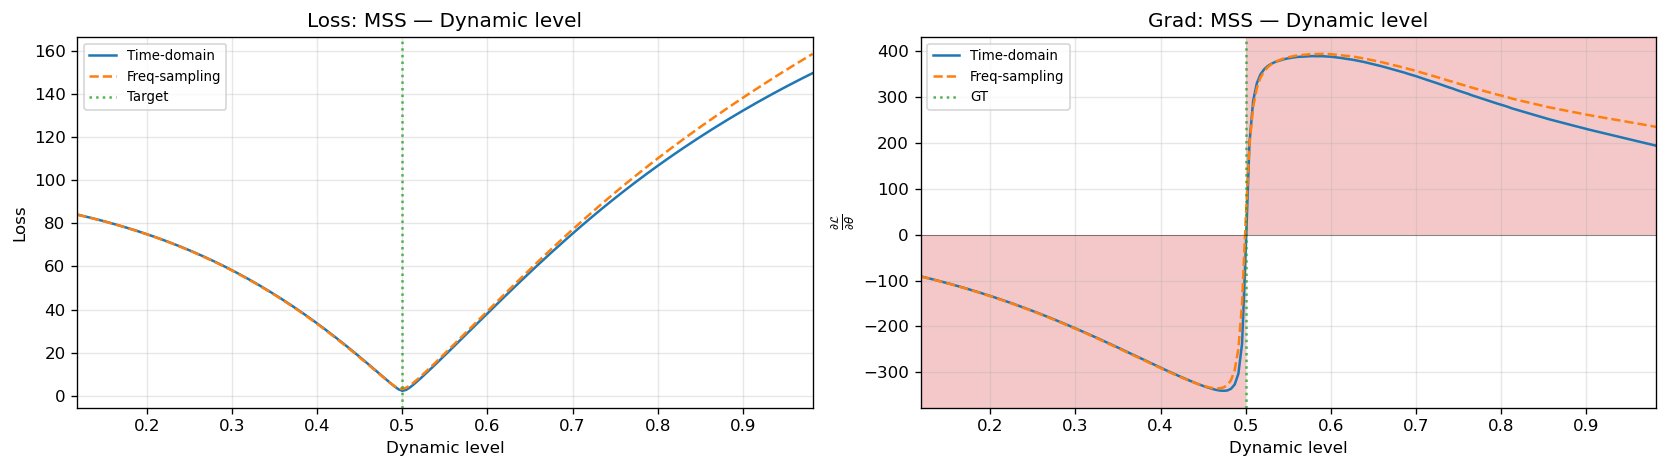

dynamic_level SOT TD:   0%|          | 0/200 [00:00<?, ?it/s]

dynamic_level SOT FS:   0%|          | 0/200 [00:00<?, ?it/s]

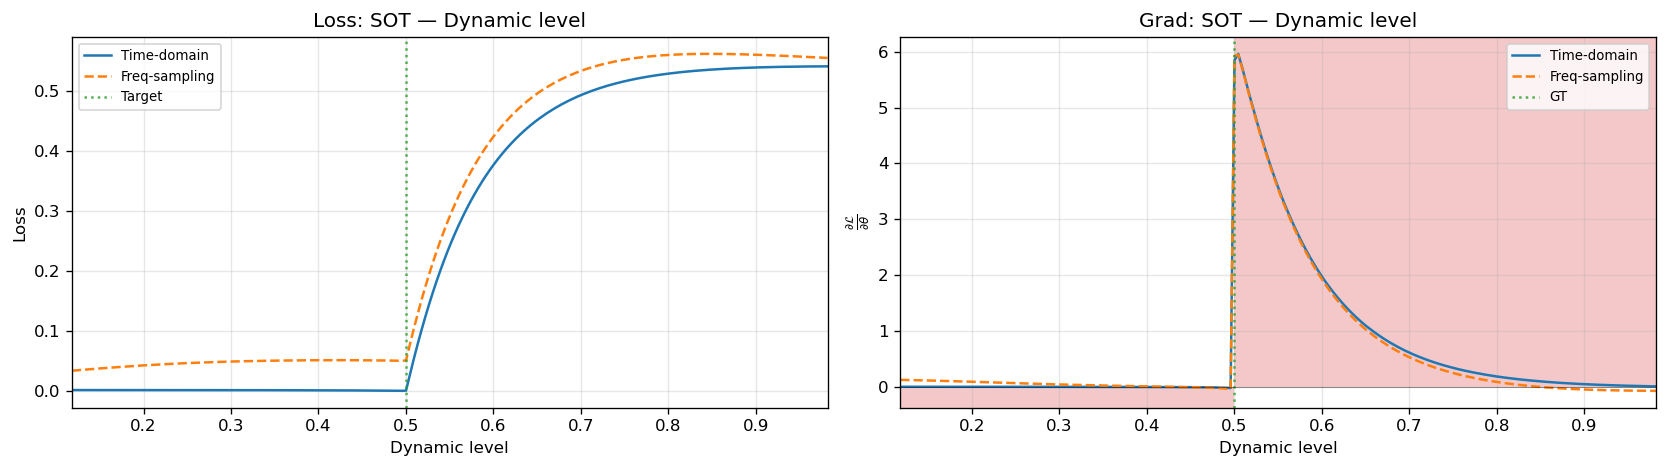

In [28]:
key = "dynamic_level"
cfg = SWEEP_CFG[key]
sweep = np.linspace(cfg["lo"], cfg["hi"], N_SWEEP)
gt = _to_device(GT_PARAMS)
gt_val = GT_PARAMS[key].item()

print(f"Sweeping {key} — GT = {gt_val:.4f}, range = [{cfg['lo']:.4f}, {cfg['hi']:.4f}]")

# ── MSS ──
mss_td_loss, mss_td_grad = compute_landscape_with_grad(
    synth_td, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS TD")
mss_fs_loss, mss_fs_grad = compute_landscape_with_grad(
    synth_fs, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   mss_td_loss, mss_td_grad, mss_fs_loss, mss_fs_grad, "MSS")

# ── SOT ──
sot_td_loss, sot_td_grad = compute_landscape_with_grad(
    synth_td, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT TD")
sot_fs_loss, sot_fs_grad = compute_landscape_with_grad(
    synth_fs, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   sot_td_loss, sot_td_grad, sot_fs_loss, sot_fs_grad, "SOT")

# ── Stash for summary ──
if "results" not in dir(): results = {}
results[key] = {
    "sweep": sweep, "gt": gt_val, "label": cfg["label"],
    "mss_td": (mss_td_loss, mss_td_grad),
    "mss_fs": (mss_fs_loss, mss_fs_grad),
    "sot_td": (sot_td_loss, sot_td_grad),
    "sot_fs": (sot_fs_loss, sot_fs_grad),
}

---
## `burst_gain`

Sweeping burst_gain — GT = 0.9000, range = [0.0200, 0.9800]


burst_gain MSS TD:   0%|          | 0/200 [00:00<?, ?it/s]

burst_gain MSS FS:   0%|          | 0/200 [00:00<?, ?it/s]

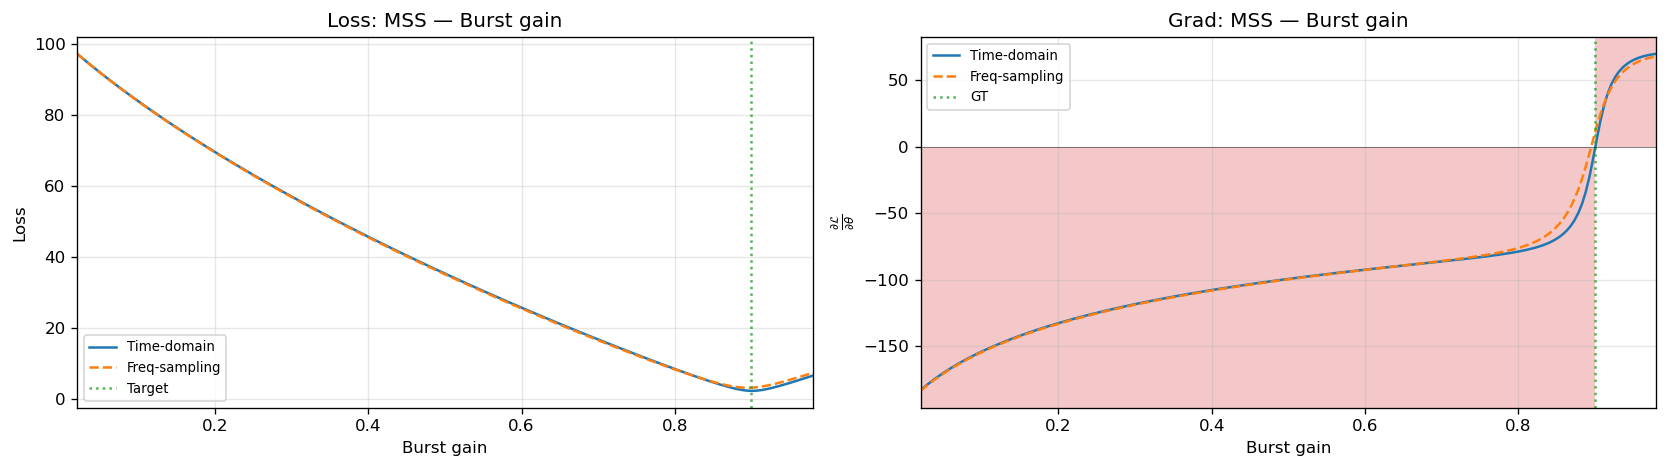

burst_gain SOT TD:   0%|          | 0/200 [00:00<?, ?it/s]

burst_gain SOT FS:   0%|          | 0/200 [00:00<?, ?it/s]

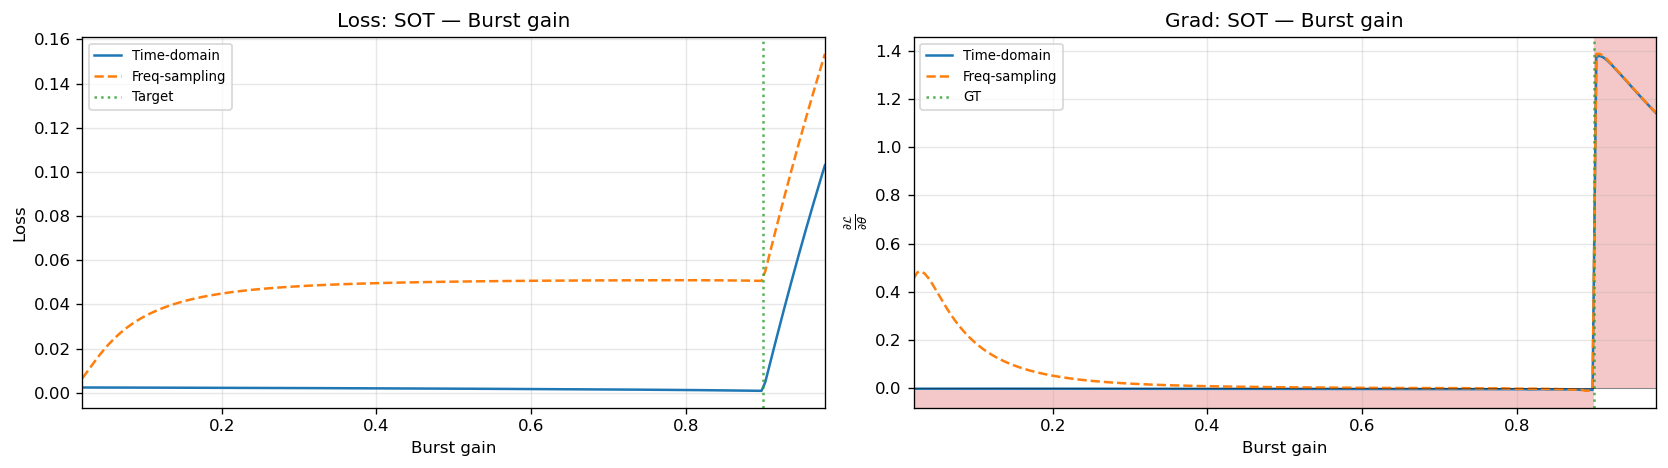

In [29]:
key = "burst_gain"
cfg = SWEEP_CFG[key]
sweep = np.linspace(cfg["lo"], cfg["hi"], N_SWEEP)
gt = _to_device(GT_PARAMS)
gt_val = GT_PARAMS[key].item()

print(f"Sweeping {key} — GT = {gt_val:.4f}, range = [{cfg['lo']:.4f}, {cfg['hi']:.4f}]")

# ── MSS ──
mss_td_loss, mss_td_grad = compute_landscape_with_grad(
    synth_td, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS TD")
mss_fs_loss, mss_fs_grad = compute_landscape_with_grad(
    synth_fs, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   mss_td_loss, mss_td_grad, mss_fs_loss, mss_fs_grad, "MSS")

# ── SOT ──
sot_td_loss, sot_td_grad = compute_landscape_with_grad(
    synth_td, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT TD")
sot_fs_loss, sot_fs_grad = compute_landscape_with_grad(
    synth_fs, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   sot_td_loss, sot_td_grad, sot_fs_loss, sot_fs_grad, "SOT")

# ── Stash for summary ──
if "results" not in dir(): results = {}
results[key] = {
    "sweep": sweep, "gt": gt_val, "label": cfg["label"],
    "mss_td": (mss_td_loss, mss_td_grad),
    "mss_fs": (mss_fs_loss, mss_fs_grad),
    "sot_td": (sot_td_loss, sot_td_grad),
    "sot_fs": (sot_fs_loss, sot_fs_grad),
}

---
## `time`

Sweeping time — GT = 0.3000, range = [0.0150, 0.7350]


time MSS TD:   0%|          | 0/200 [00:00<?, ?it/s]

time MSS FS:   0%|          | 0/200 [00:00<?, ?it/s]

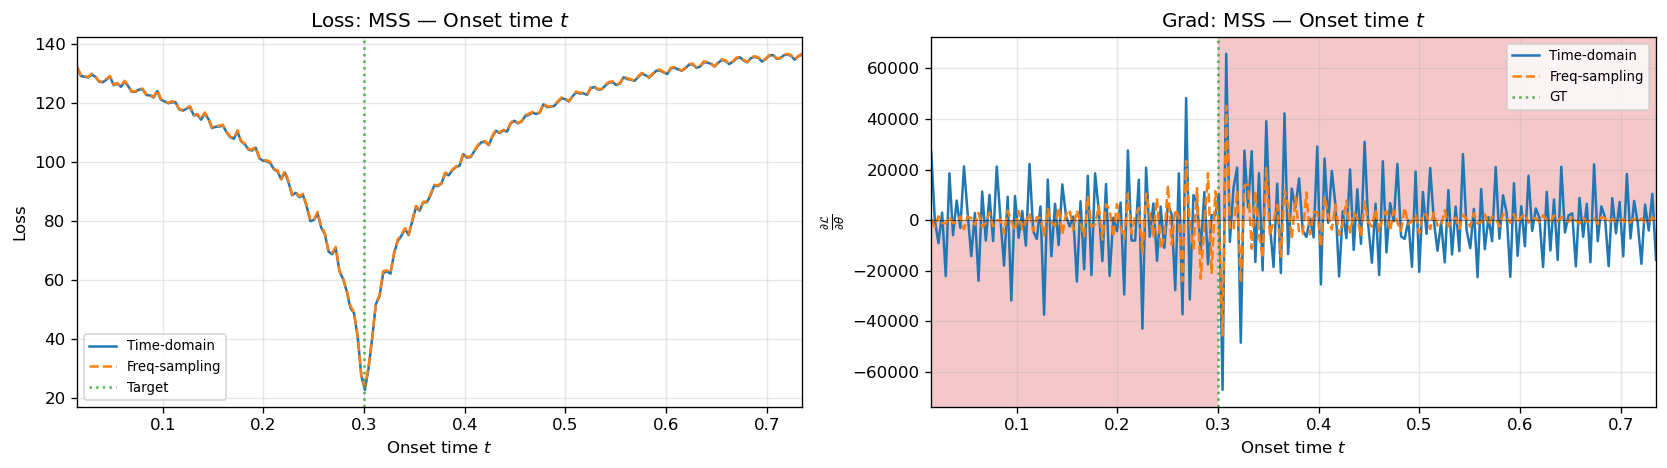

time SOT TD:   0%|          | 0/200 [00:00<?, ?it/s]

time SOT FS:   0%|          | 0/200 [00:00<?, ?it/s]

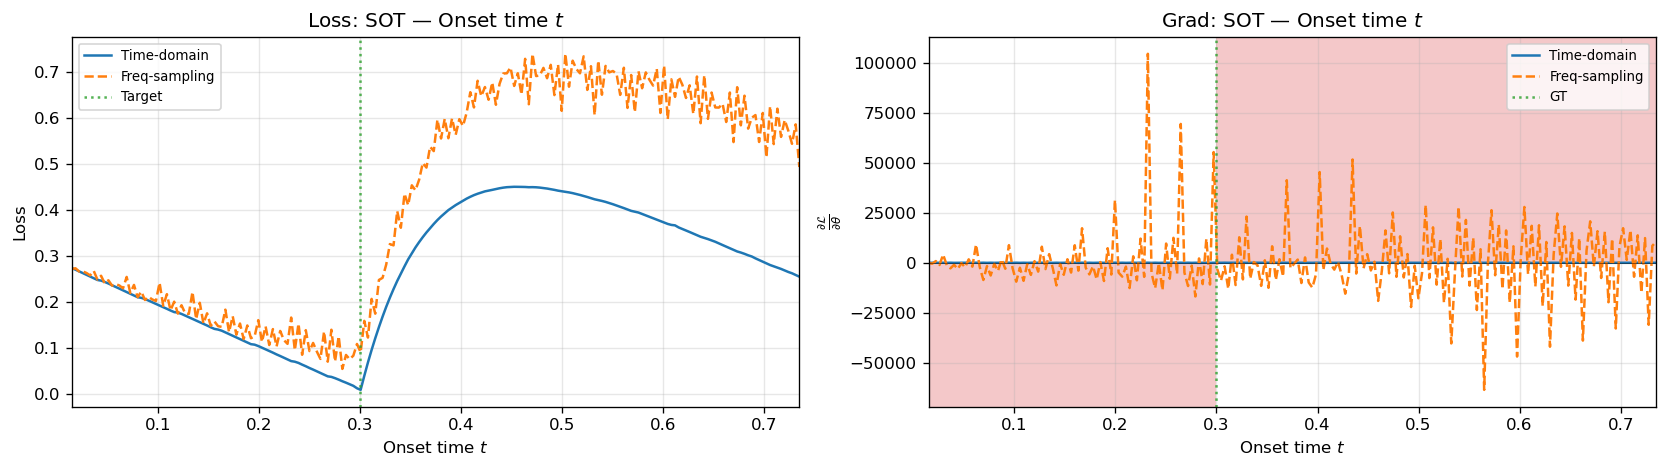

In [30]:
key = "time"
cfg = SWEEP_CFG[key]
sweep = np.linspace(cfg["lo"], cfg["hi"], N_SWEEP)
gt = _to_device(GT_PARAMS)
gt_val = GT_PARAMS[key].item()

print(f"Sweeping {key} — GT = {gt_val:.4f}, range = [{cfg['lo']:.4f}, {cfg['hi']:.4f}]")

# ── MSS ──
mss_td_loss, mss_td_grad = compute_landscape_with_grad(
    synth_td, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS TD")
mss_fs_loss, mss_fs_grad = compute_landscape_with_grad(
    synth_fs, mss_fn, key, sweep, gt, target_audio, desc=f"{key} MSS FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   mss_td_loss, mss_td_grad, mss_fs_loss, mss_fs_grad, "MSS")

# ── SOT ──
sot_td_loss, sot_td_grad = compute_landscape_with_grad(
    synth_td, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT TD")
sot_fs_loss, sot_fs_grad = compute_landscape_with_grad(
    synth_fs, sot_fn, key, sweep, gt, target_audio, desc=f"{key} SOT FS")

plot_loss_and_grad(sweep, gt_val, cfg["label"],
                   sot_td_loss, sot_td_grad, sot_fs_loss, sot_fs_grad, "SOT")

# ── Stash for summary ──
if "results" not in dir(): results = {}
results[key] = {
    "sweep": sweep, "gt": gt_val, "label": cfg["label"],
    "mss_td": (mss_td_loss, mss_td_grad),
    "mss_fs": (mss_fs_loss, mss_fs_grad),
    "sot_td": (sot_td_loss, sot_td_grad),
    "sot_fs": (sot_fs_loss, sot_fs_grad),
}

---
## Summary figure — all parameters

Saved → landscape_summary.png


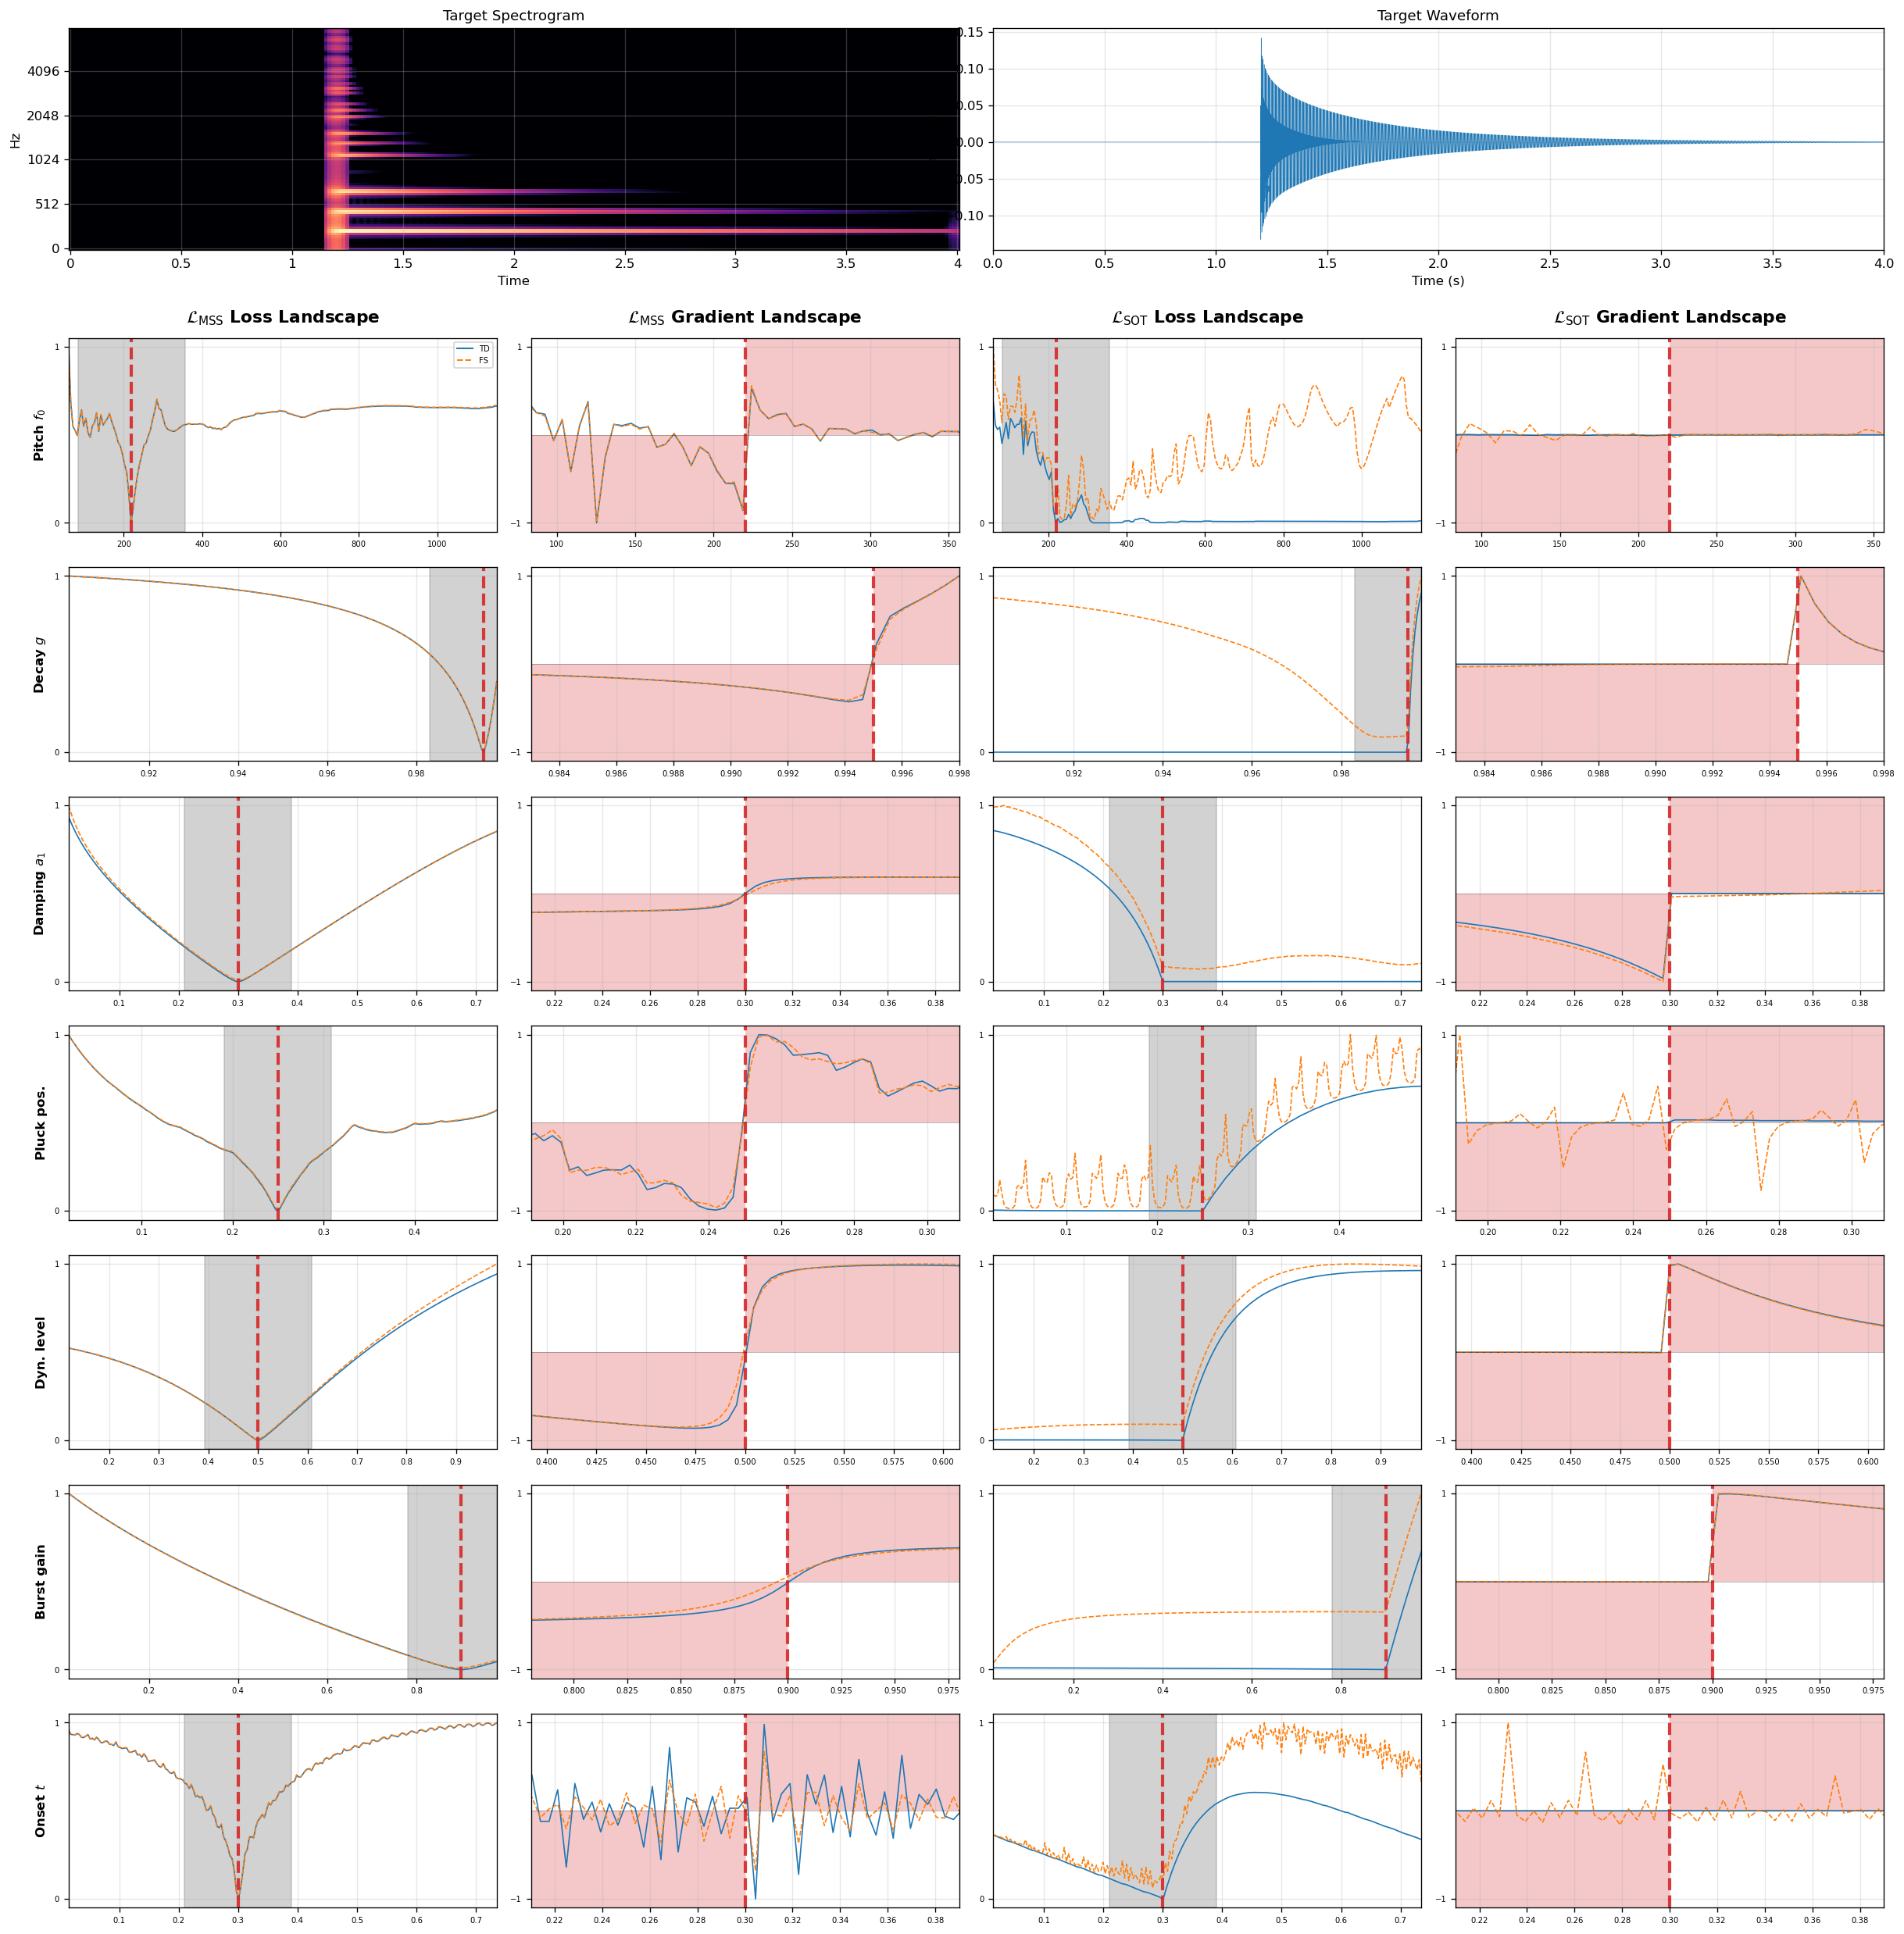

In [68]:
n_params = len(PARAM_ORDER)
n_cols = 4
n_data_rows = n_params

ROW_H = 2.8
TOP_H = 3.2
SPACER_H = 0.25

fig_h = TOP_H + SPACER_H + ROW_H * n_data_rows
fig_w = 22

fig = plt.figure(figsize=(fig_w, fig_h))

height_ratios = [TOP_H, SPACER_H] + [ROW_H] * n_data_rows

gs = fig.add_gridspec(
    2 + n_data_rows, n_cols,
    height_ratios=height_ratios,
    hspace=0.2, wspace=0.08,
    left=0.09, right=0.97,
    top=0.90,
    bottom=0.03,
)

ax_spec = fig.add_subplot(gs[0, 0:2])
S = librosa.feature.melspectrogram(y=target_np, sr=FS, n_fft=2048, hop_length=256, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_db, sr=FS, hop_length=256, x_axis='time', y_axis='mel', ax=ax_spec)
ax_spec.set_title("Target Spectrogram", fontsize=11)

ax_wav = fig.add_subplot(gs[0, 2:4])
t_axis = np.arange(NUM_SAMPLES) / FS
ax_wav.plot(t_axis, target_np, linewidth=0.3, color='tab:blue')
ax_wav.set_xlabel("Time (s)")
ax_wav.set_ylabel("Amplitude")
ax_wav.set_title("Target Waveform", fontsize=11)
ax_wav.set_xlim(0, NUM_SAMPLES / FS)

col_configs = [
    ('mss', 0, False),
    ('mss', 1, True),
    ('sot', 0, False),
    ('sot', 1, True),
]

PARAM_DISPLAY = {
    "f0": r"Pitch $f_0$",
    "decay": r"Decay $g$",
    "a1": r"Damping $a_1$",
    "pluck_position": "Pluck pos.",
    "dynamic_level": "Dyn. level",
    "burst_gain": "Burst gain",
    "time": r"Onset $t$",
}

header_titles = [
    r'$\mathcal{L}_{\mathrm{MSS}}$ Loss Landscape',
    r'$\mathcal{L}_{\mathrm{MSS}}$ Gradient Landscape',
    r'$\mathcal{L}_{\mathrm{SOT}}$ Loss Landscape',
    r'$\mathcal{L}_{\mathrm{SOT}}$ Gradient Landscape'
]

axes_in_row = []

for row_i, key in enumerate(PARAM_ORDER):
    r = results[key]
    sweep = r['sweep']
    gt_val = r['gt']

    # ── CALCULATE ZOOM BOUNDS ONCE PER ROW ──
    sweep_range = sweep[-1] - sweep[0]
    zoom_span = 0.25 * sweep_range
    zoom_x_min = max(sweep[0], gt_val - zoom_span / 2)
    zoom_x_max = min(sweep[-1], gt_val + zoom_span / 2)

    axes_in_row = []
    for col_i, (prefix, data_idx, is_grad) in enumerate(col_configs):
        ax = fig.add_subplot(gs[row_i + 2, col_i])
        axes_in_row.append(ax)

        td_data = np.array(r[f'{prefix}_td'][data_idx])
        fs_data = np.array(r[f'{prefix}_fs'][data_idx])

        if not is_grad:
            val_min = min(np.min(td_data), np.min(fs_data))
            val_max = max(np.max(td_data), np.max(fs_data))
            val_range = val_max - val_min if val_max > val_min else 1.0

            td_data = (td_data - val_min) / val_range
            fs_data = (fs_data - val_min) / val_range

            ax.set_ylim(-0.05, 1.05)
            ax.set_yticks([0.0, 1.0])

        else:
            max_abs = max(np.max(np.abs(td_data)), np.max(np.abs(fs_data)))
            max_abs = max_abs if max_abs > 0 else 1.0

            td_data = td_data / max_abs
            fs_data = fs_data / max_abs

            ax.set_ylim(-1.1, 1.1)
            ax.set_yticks([-1.0, 1.0])

        ax.plot(sweep, td_data, color="tab:blue", linewidth=1.0)
        ax.plot(sweep, fs_data, color="tab:orange", linewidth=1.0, linestyle="--")
        ax.axvline(gt_val, color="tab:red", linestyle="--", linewidth=2.5, alpha=0.9)

        # ── APPLY ZOOM HIGHLIGHT OR X-LIMITS ──
        if is_grad:
            ax.set_xlim(zoom_x_min, zoom_x_max)
            ax.axhline(0, color="black", linewidth=0.4, alpha=0.4)
            _shade_correct_gradient_regions(ax, sweep, gt_val)
        else:
            ax.set_xlim(sweep[0], sweep[-1])
            # Draw the semi-transparent grey block indicating the zoom region
            ax.axvspan(zoom_x_min, zoom_x_max, color='grey', alpha=0.35, zorder=0)

        ax.tick_params(labelsize=6)

        if row_i == 0:
            ax.set_title(header_titles[col_i], fontsize=13, fontweight='bold', pad=12)

        if row_i == 0 and col_i == 0:
            ax.plot([], [], color='tab:blue', linewidth=1.2, label='TD')
            ax.plot([], [], color='tab:orange', linewidth=1.2, linestyle='--', label='FS')
            ax.legend(fontsize=6, loc='upper right')

    ax_pos = axes_in_row[0].get_position()
    fig.text(
        ax_pos.x0 - 0.01, ax_pos.y0 + ax_pos.height / 2,
        PARAM_DISPLAY[key],
        ha='right', va='center', fontsize=10, fontweight='bold',
        rotation=90,
    )

fig.savefig("landscape_summary.png", dpi=150, bbox_inches="tight")
print("Saved → landscape_summary.png")
plt.show()